In [ ]:
# The normal imports
import numpy as np
import pandas as pd

# Import the stats librayr from numpy
from scipy import stats
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# These are the plotting modules adn libraries we'll use
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Command so that plots appear in the ipython Notebook
%matplotlib inline

**Loadind data directly from Kaggle to Google Colab without downloading it**

In [ ]:
# install kagglehub
!pip install kagglehub -q

import kagglehub
import os

#load data from Kaggle
path = kagglehub.dataset_download("kzmontage/e-commerce-website-logs")

# read file as CSV
csv_path = os.path.join(path, "E-commerce Website Logs.csv")
df = pd.read_csv(csv_path)
df.head()

Using Colab cache for faster access to the 'e-commerce-website-logs' dataset.


/tmp/ipython-input-2703118114.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
0,2017-03-14 17:43:57.172,2533,TCP,1.10.195.126,20100,Chrome,28,Female,CA,Normal,English,261.9600,No,0.0,Credit Card
1,2017-03-14 17:43:57.172,4034,TCP,1.1.217.211,20500,Mozilla Firefox,21,Male,AR,Normal,English,731.9400,No,0.0,Debit Card
2,2017-03-14 17:43:26.135,1525,TCP,1.115.198.107,90100,Mozilla Firefox,20,Male,PL,Normal,English,14.6200,No,0.0,Cash
3,2017-03-14 17:43:26.135,4572,TCP,1.121.152.143,100300,Mozilla Firefox,66,Female,IN,Normal,Spanish,957.5775,No,0.0,Credit Card
4,2017-03-14 18:17:09.005,3652,TCP,1.123.135.213,270200,Mozilla Firefox,53,Female,KR,Normal,Spanish,22.3680,No,0.0,Cash


**Handling Missing Data:**


*   summary stats to locate null values
*   Use visual tools like Heatmaps (sns.heatmap)
*   Apply appropriate techniques (Deletion, Mean/Median Imputation, or Predictive filling). Justify why you chose one over the other.


Initially, we used `info()` to determine the details of the columns in the table. Then, we used `df.isnull().sum()` to identify the null values ​​in the columns. The result was that only one column contained null values, namely `age`. We also verified this using `sns.heatmap()`.




In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172838 entries, 0 to 172837
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   accessed_date     172838 non-null  object 
 1   duration_(secs)   172838 non-null  int64  
 2   network_protocol  172838 non-null  object 
 3   ip                172838 non-null  object 
 4   bytes             172838 non-null  int64  
 5   accessed_Ffom     172838 non-null  object 
 6   age               99457 non-null   object 
 7   gender            172838 non-null  object 
 8   country           172838 non-null  object 
 9   membership        172838 non-null  object 
 10  language          172838 non-null  object 
 11  sales             172838 non-null  float64
 12  returned          172838 non-null  object 
 13  returned_amount   172838 non-null  float64
 14  pay_method        172838 non-null  object 
dtypes: float64(2), int64(2), object(11)
memory usage: 19.8+ MB


**Handling Missing Data:**

In [ ]:
df.isnull().sum()

,0
accessed_date,0
duration_(secs),0
network_protocol,0
ip,0
bytes,0
accessed_Ffom,0
age,73381
gender,0
country,0
membership,0


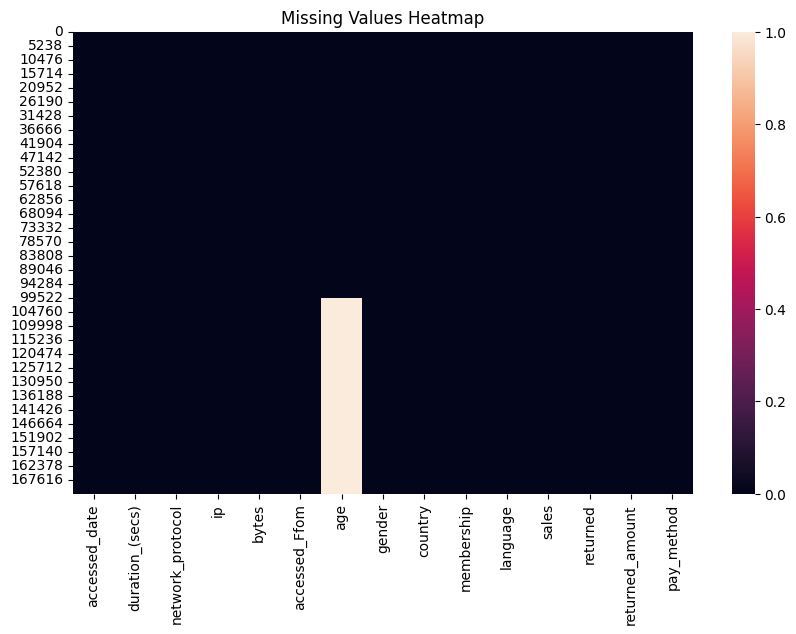

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull())
plt.title("Missing Values Heatmap")
plt.show()

**To handle the null values ​​in the age column, we initially created a boxplot for the age column to better understand the data. Since the number of null values ​​constitutes 42% of the data, it makes sense not to delete them. We decided to use the median because the values ​​contain a large number of null values, so it's better to use the median instead of the mean.**

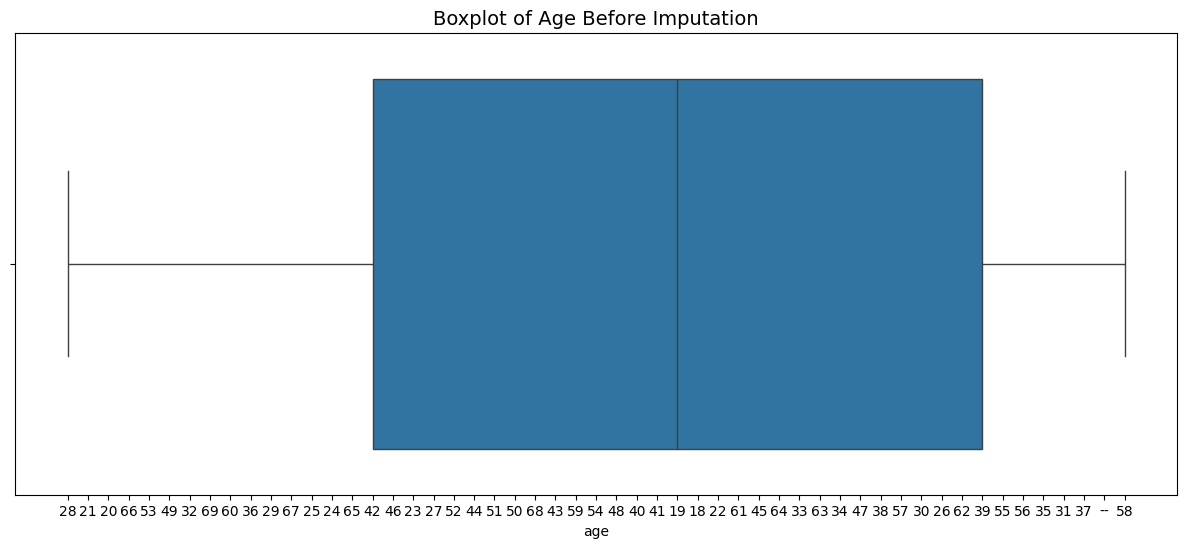

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age Before Imputation", fontsize=14)
plt.show()

In [ ]:
df_cleaned = df
df_cleaned['age'] = pd.to_numeric(df['age'], errors='coerce') #convart value from strig to number
median_age = df['age'].median()
df_cleaned['age'] = df['age'].fillna(median_age)
df_cleaned['age'] = df['age'].round().astype(int)   # here when i display the value from age data type that was as float which is not logic so i convartthe typr to ineder


In [ ]:
# The resualt after apply handle
df_cleaned.isnull().sum()

,0
accessed_date,0
duration_(secs),0
network_protocol,0
ip,0
bytes,0
accessed_Ffom,0
age,0
gender,0
country,0
membership,0


**Outlier Treatment:**
*   Use Boxplots to visualize extreme values (The "Outliers" we discussed).
*   Apply IQR (Interquartile Range) or Winsorization to handle these points.



In [ ]:
df_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_(secs),172838.0,3248.031827,1010.872270,1500.0,2371.00,3246.00,4124.00,5000.000
bytes,172838.0,1535.206858,6349.555845,28.0,264.00,589.00,2430.00,932858.000
age,172838.0,43.214808,10.489798,18.0,43.00,43.00,43.00,69.000
sales,172838.0,411.346449,785.537868,0.0,5.23,46.92,600.16,11199.968
returned_amount,172838.0,74.012092,364.446435,0.0,0.00,0.00,0.00,22638.480


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


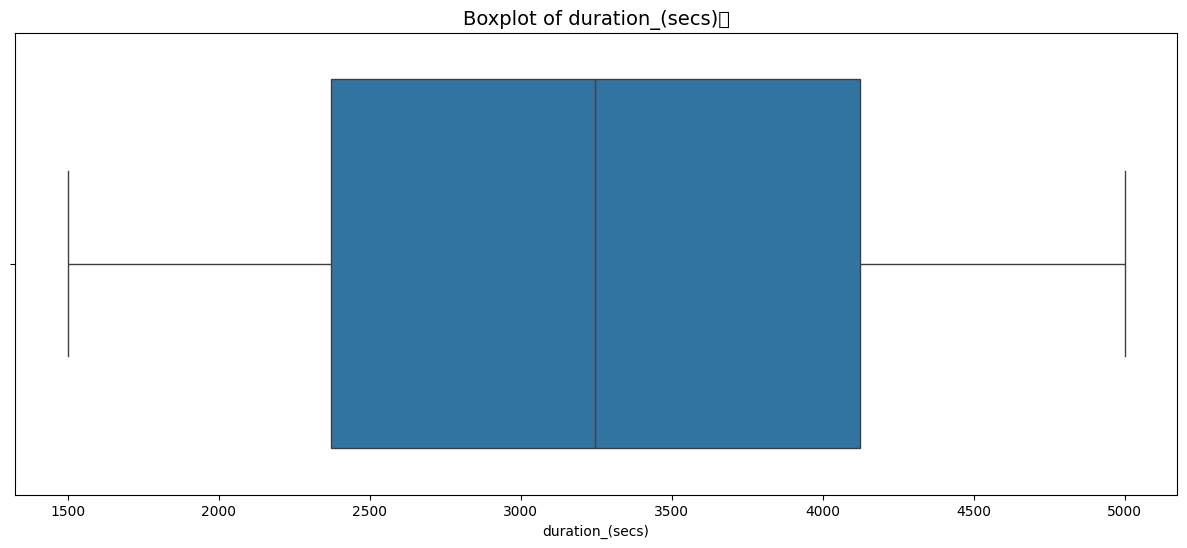

In [ ]:
# Boxplot of duration_(secs)
plt.figure(figsize=(15,6))
sns.boxplot(x=df['duration_(secs)'])
plt.title("Boxplot of duration_(secs)	", fontsize=14)
plt.show()

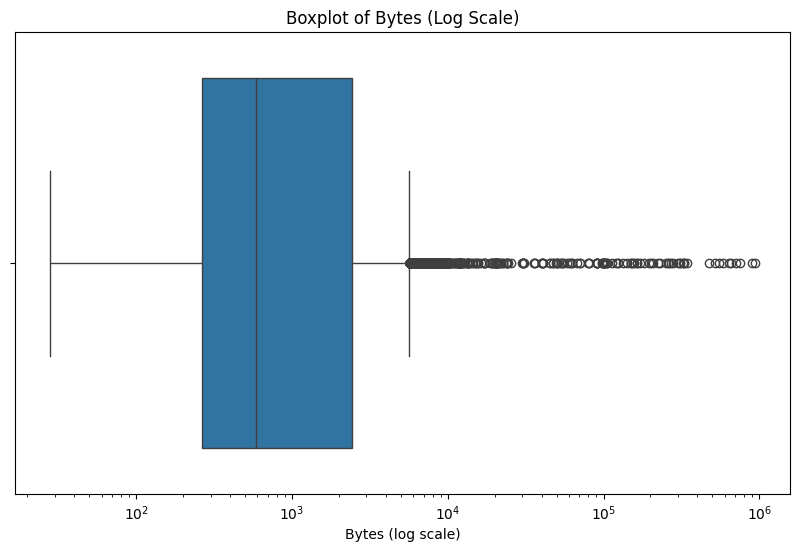

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


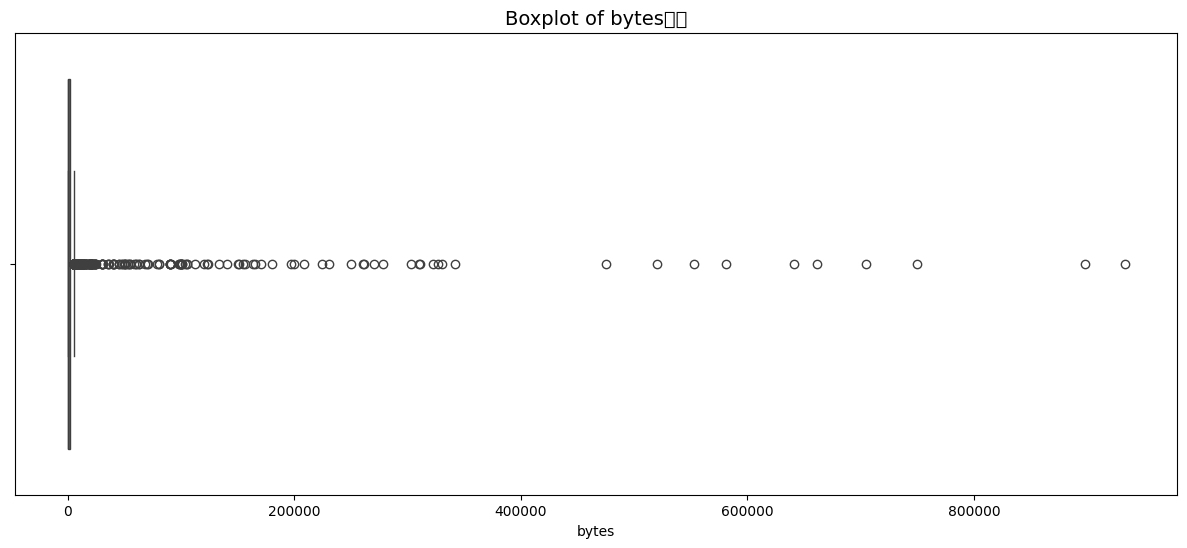

In [ ]:
# Boxplot of Bytes (Log Scale)
#we use the log-log scale due to the value is to large so the boxplot not clear the value as show in 2 figher below
plt.figure(figsize=(10,6))
sns.boxplot(x=df['bytes'])

plt.xscale('log')  #transform log-log scale due to the range vary larg

plt.title("Boxplot of Bytes (Log Scale)")
plt.xlabel("Bytes (log scale)")
plt.show()

# Boxplot of Bytes (orginal figar)
plt.figure(figsize=(15,6))
sns.boxplot(x=df['bytes'])
plt.title("Boxplot of bytes		", fontsize=14)
plt.show()

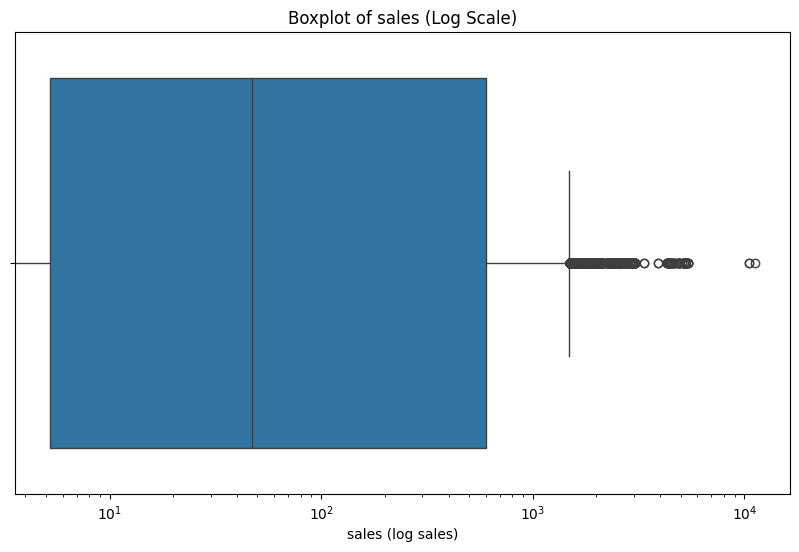

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


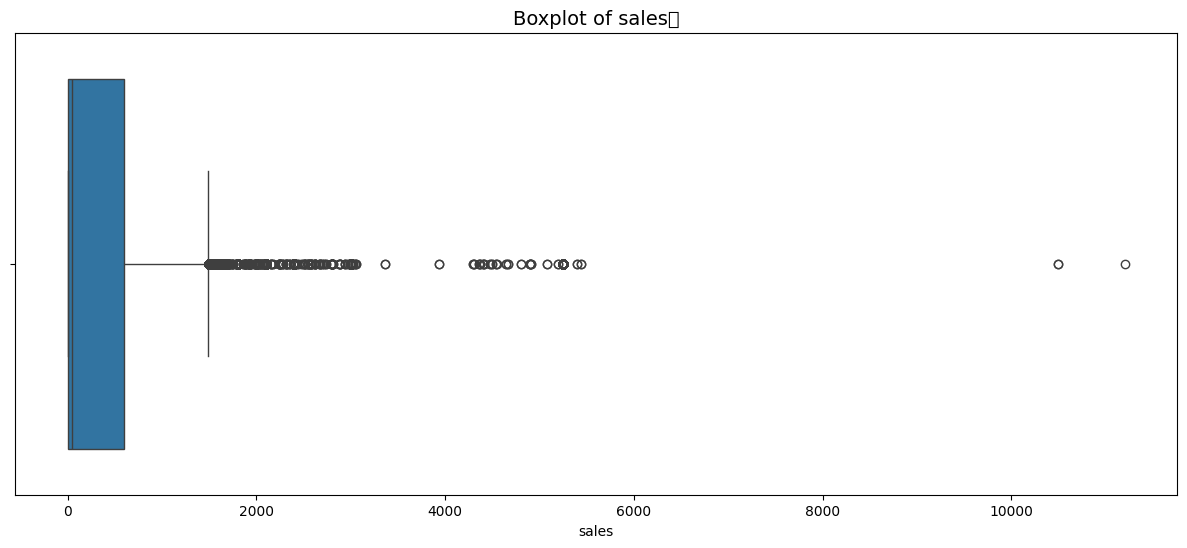

In [ ]:
# Boxplot of sales (Log Scale)
plt.figure(figsize=(10,6))
sns.boxplot(x=df['sales'])

plt.xscale('log')  #transform log-log scale due to the range vary larg

plt.title("Boxplot of sales (Log Scale)")
plt.xlabel("sales (log sales)")
plt.show()


# Boxplot of sales (orginal figar)
plt.figure(figsize=(15,6))
sns.boxplot(x=df['sales'])
plt.title("Boxplot of sales	", fontsize=14)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


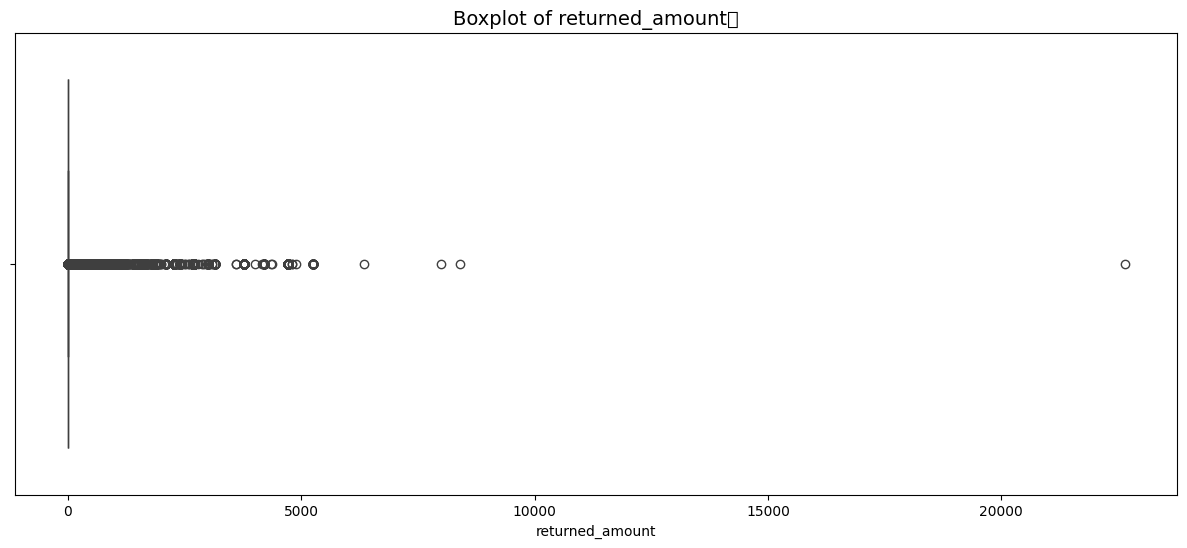

In [ ]:
# Boxplot of returned_amount
plt.figure(figsize=(15,6))
sns.boxplot(x=df['returned_amount'])
plt.xlabel("returned_amount")
plt.title("Boxplot of returned_amount	", fontsize=14)
plt.show()

**Columns with very large outliers:**
`bytes` : Contains some very large values ​​compared to most of the data, which may affect the mean and standard deviation.

`sales` : Some values ​​are very high compared to the rest of the sales figures, representing outliers.

`returned_amount` : Most values ​​are zero, but there are some very large values, which are clear outliers.

**Columns that do not need outlier handling:**

`duration_(secs)` : The distribution is almost normal; there are no large outliers affecting the analysis.

`age` : After handling missing values, most of the data is concentrated around a single value (Median), and there are no significant outliers.



**To handle outliers without data loss, it is best to apply `Winsorization` to the bytes, sales, and returned_amount columns, while leaving the duration_(secs) and age columns as they are because they do not contain significant outliers.**

**Benefits of Winsorization**
-  Protects statistical analysis: Reduces the impact of outliers on the mean and standard deviation.
-  Preserves all data; no rows are deleted.
-  Improves model performance
-  Applies to any numbered column using Scipy or Pandas.

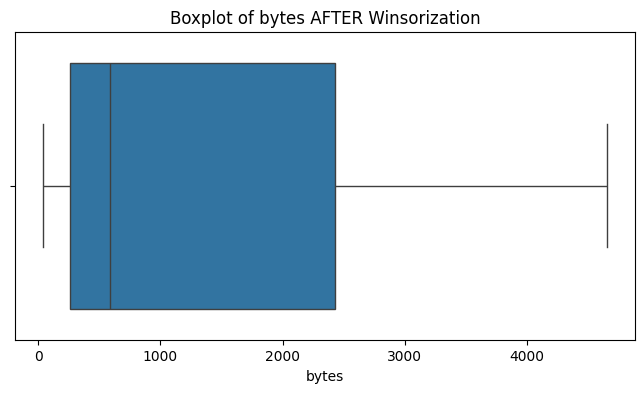

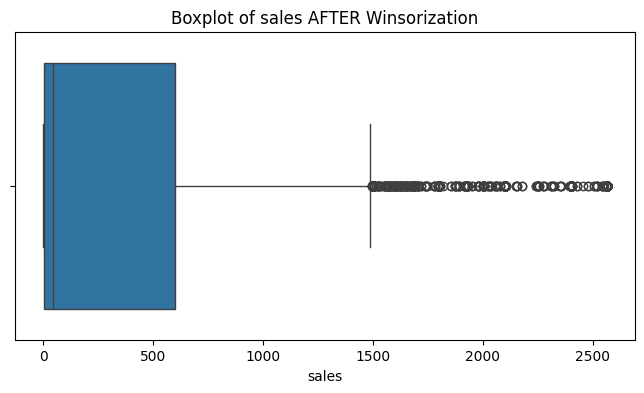

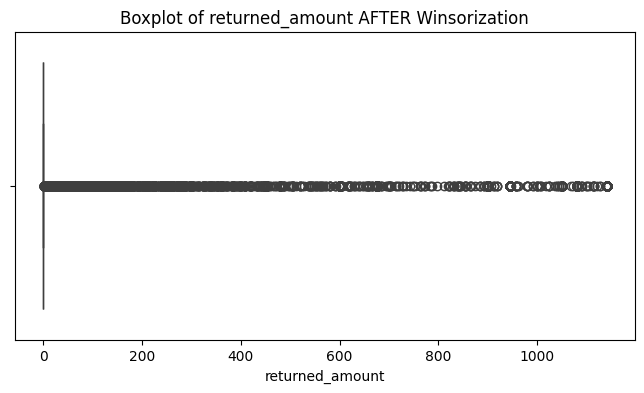

In [ ]:
cols_to_winsor = ['bytes', 'sales', 'returned_amount']   #Identify the columns containing Outliers
limits = [0.025, 0.025]  # 2.5% from bottom and top

for col in cols_to_winsor:
    df_cleaned[col] = winsorize(df_cleaned[col], limits=limits)

for col in cols_to_winsor:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f'Boxplot of {col} AFTER Winsorization')
    plt.show()

In [ ]:
print(df_cleaned[cols_to_winsor].describe())


               bytes          sales  returned_amount
count  172838.000000  172838.000000    172838.000000
mean     1385.587828     381.427171        53.210506
std      1366.733572     650.076532       212.583083
min        40.000000       0.000000         0.000000
25%       264.000000       5.230000         0.000000
50%       589.000000      46.920000         0.000000
75%      2430.000000     600.160000         0.000000
max      4651.000000    2563.056000      1140.304000


**after Winsorization**
- The mean decreased slightly after Winsorization because large outliers no
longer significantly impacted the calculation.

- The standard deviation decreased considerably; the data distribution became less dispersed and more representative.

- The upper limit (Max) now makes sense  there are no longer huge gaps between the extreme values ​​and the upper percentiles.

- The 25%, 50%, and 75% percentiles remained unchanged  most of the data stayed the same; only the outliers were adjusted.

**Feature Transformation:**
*   Perform Data Type Conversions (e.g., changing strings to dates).
*   Apply Encoding for categorical variables and Scaling/Normalization for numerical features where necessary.

In [ ]:
df['accessed_date'] = pd.to_datetime(df['accessed_date'])
df.head()

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
0,2017-03-14 17:43:57.172,2533,TCP,1.10.195.126,4651,Chrome,28,Female,CA,Normal,English,261.9600,No,0.0,Credit Card
1,2017-03-14 17:43:57.172,4034,TCP,1.1.217.211,4651,Mozilla Firefox,21,Male,AR,Normal,English,731.9400,No,0.0,Debit Card
2,2017-03-14 17:43:26.135,1525,TCP,1.115.198.107,4651,Mozilla Firefox,20,Male,PL,Normal,English,14.6200,No,0.0,Cash
3,2017-03-14 17:43:26.135,4572,TCP,1.121.152.143,4651,Mozilla Firefox,66,Female,IN,Normal,Spanish,957.5775,No,0.0,Credit Card
4,2017-03-14 18:17:09.005,3652,TCP,1.123.135.213,4651,Mozilla Firefox,53,Female,KR,Normal,Spanish,22.3680,No,0.0,Cash


In [ ]:
#Checking categorical variables and the number of unique values
#This is important to determine which column needs Label Encoding (high cardinality) and which column needs One-Hot Encoding (low cardinality).
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['network_protocol','gender', 'membership', 'returned','pay_method', 'country', 'language','accessed_Ffom']
print("InCategorical Columns Before Encoding:")

data = {
    "Column": categorical_cols,
    "Unique Values": [df[col].nunique() for col in categorical_cols]
}

df_summary = pd.DataFrame(data)
df_summary

InCategorical Columns Before Encoding:


,Column,Unique Values
0,network_protocol,5
1,gender,3
2,membership,3
3,returned,2
4,pay_method,4
5,country,27
6,language,30
7,accessed_Ffom,8


In [ ]:
#Label Encoding for columns with high cardinality
#This method is suitable for columns that contain many values ​​such as country, language, and accessed_Ffom.
label_encoder = LabelEncoder()  #LabelEncoder converts each text value into a number.
df_cleaned['country_encoded'] =label_encoder.fit_transform(df_cleaned['country'])
df_cleaned['language_encoded'] =label_encoder.fit_transform(df_cleaned['language'])
df_cleaned['accessed_Ffom_encoded'] = label_encoder.fit_transform(df_cleaned['accessed_Ffom'])


In [ ]:
#One-Hot Encoding for Low Cardinality Columns
#It converts nominal columns with low values ​​into binary columns (0/1).
onehot_cols = ['network_protocol', 'gender','membership', 'returned', 'pay_method']
df_cleaned = pd.get_dummies(df_cleaned, columns=onehot_cols, prefix=onehot_cols, drop_first=True)
#drop_first=True to avoid Dummy Variable Trap (number of columns less than 1)

In [ ]:
#Delete unused original columns
#We deleted the original columns because we encoded them or because they are high cardinality (ip).
df_cleaned = df_cleaned.drop(['country','language', 'accessed_Ffom', 'ip'], axis=1)
print(f"InFinal shape after encoding:{df_cleaned.shape}") #The new number of rows and columns after coding.


InFinal shape after encoding:(172838, 21)


In [ ]:
#Scaling / Normalization of Digital Columns
numeric_features = ['duration_(secs)','bytes', 'sales', 'returned_amount', 'age']


In [ ]:
print(df_cleaned[numeric_features].describe().T[['min', 'max', 'mean', 'std']])

                    min       max         mean          std
duration_(secs)  1500.0  5000.000  3248.031827  1010.872270
bytes              40.0  4651.000  1385.587828  1366.733572
sales               0.0  2563.056   381.427171   650.076532
returned_amount     0.0  1140.304    53.210506   212.583083
age                18.0    69.000    43.214808    10.489798


**MinMaxScaler** :  Converts values ​​between 0 and 1

**StandardScaler** :  Converts values ​​to Z-Score (mean ≈ 0, std ≈ 1)

In [ ]:
df_minmax = df_cleaned.copy()
df_standard = df_cleaned.copy()

minmax_scaler = MinMaxScaler()
df_minmax[numeric_features] = minmax_scaler.fit_transform(df_minmax[numeric_features])

std_scaler = StandardScaler()
df_standard[numeric_features] = std_scaler.fit_transform(df_standard[numeric_features])

In [ ]:
df_cleaned[numeric_features].describe()
df_minmax[numeric_features].describe()
df_standard[numeric_features].describe()

,duration_(secs),bytes,sales,returned_amount,age
count,1.728380e+05,1.728380e+05,1.728380e+05,1.728380e+05,1.728380e+05
mean,1.350885e-16,6.310436e-18,-5.669115e-17,5.788335e-17,-2.067027e-16
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.729236e+00,-9.845311e-01,-5.867436e-01,-2.503052e-01,-2.403753e+00
25%,-8.676016e-01,-8.206362e-01,-5.786984e-01,-2.503052e-01,-2.047787e-02
50%,-2.009980e-03,-5.828423e-01,-5.145673e-01,-2.503052e-01,-2.047787e-02
75%,8.665493e-01,7.641688e-01,3.364734e-01,-2.503052e-01,-2.047787e-02
max,1.733130e+00,2.389216e+00,3.355967e+00,5.113750e+00,2.458128e+00


VISUAL COMPARISON


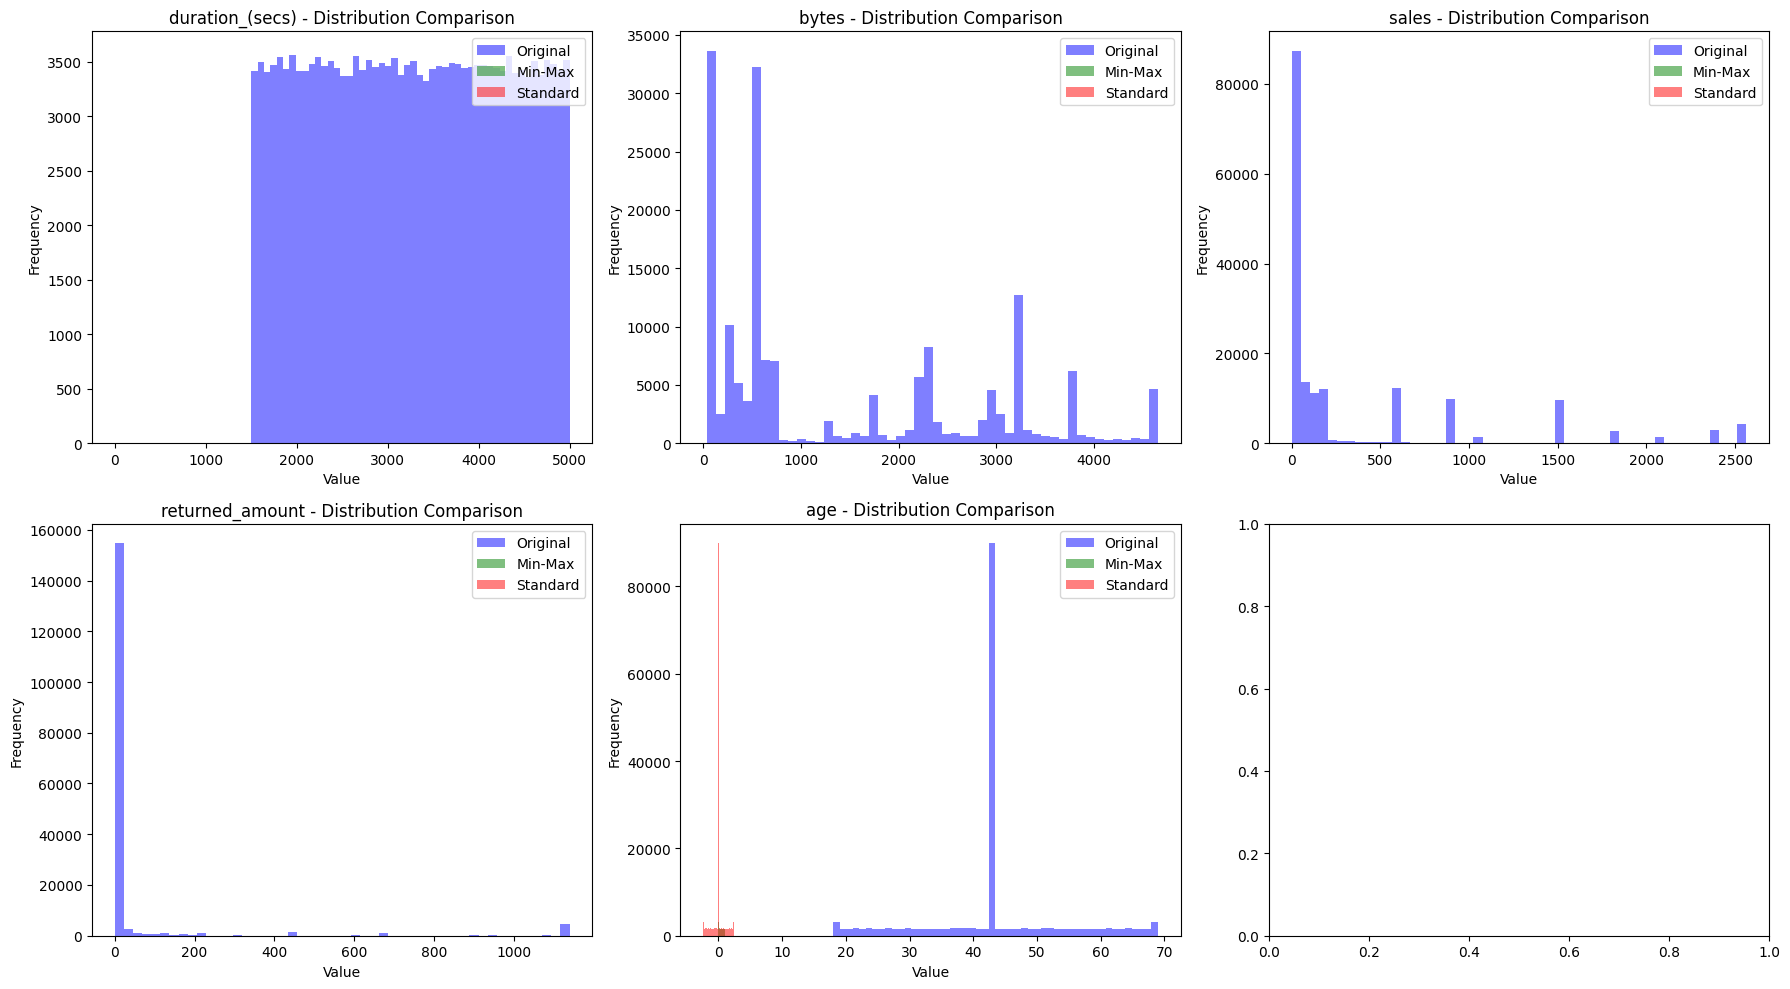

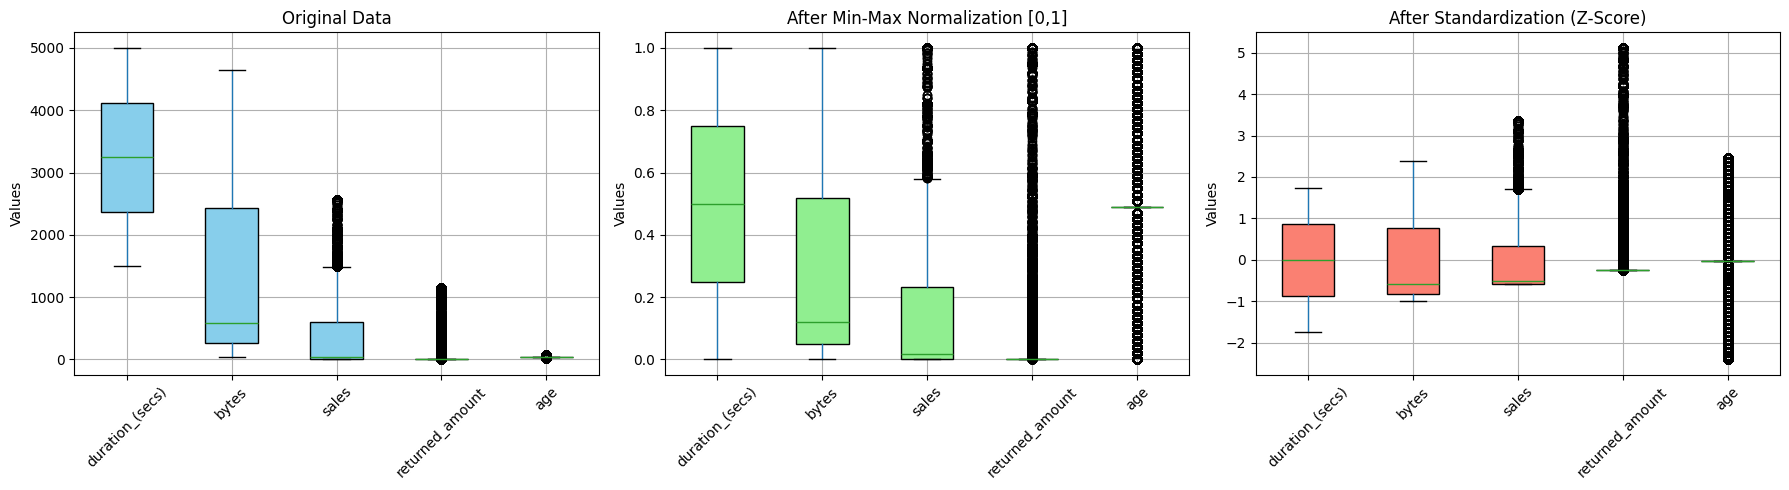


SAVING CLEANED DATA


In [ ]:
print("VISUAL COMPARISON")
print("=" *70)
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.ravel()
for i, col in enumerate(numeric_features[:5]):
  axes[i].hist(df_cleaned[col], bins=50,alpha=0.5, label='Original', color='blue')
  axes[i].hist(df_minmax[col], bins=50, alpha=0.5, label='Min-Max', color='green')
  axes[i].hist(df_standard[col], bins=50, alpha=0.5, label='Standard', color='red')
  axes[i].set_title(f'{col} - Distribution Comparison')
  axes[i].legend()
  axes[i].set_xlabel('Value')
  axes[i].set_ylabel('Frequency')
  plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(18,5))
df_cleaned[numeric_features].boxplot(ax=axes[0], patch_artist=True, boxprops=dict(facecolor='skyblue'))
axes[0].set_title('Original Data')
axes[0].set_ylabel('Values')
axes[0].tick_params(axis='x', rotation=45)
df_minmax[numeric_features].boxplot(ax=axes[1], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('After Min-Max Normalization [0,1]')
axes[1].set_ylabel('Values')
axes[1].tick_params(axis='x', rotation=45)
df_standard[numeric_features].boxplot(ax=axes[2], patch_artist=True, boxprops=dict(facecolor='salmon'))
axes[2].set_title('After Standardization (Z-Score)')
axes[2].set_ylabel('Values')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Save the new data in a new file named: Cleaned Data**

In [46]:

from google.colab import files

# save cleaned data to CSV
df_minmax.to_csv('Cleaned_Data_MinMax.csv', index=False)
df_standard.to_csv('Cleaned_Data_Standard.csv', index=False)
df_cleaned.to_csv('Cleaned_Data_Original.csv', index=False)
print("Files saved:")
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

Files saved:
PROJECT COMPLETED SUCCESSFULLY!
